In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from math import sqrt,exp
img = cv2.imread("lena.png",0)
fourier = np.fft.fft2(img)  # gerando a FFT
fourier1 =np.log(1+np.abs(fourier)) # Transformação de log para visualização da magnitude
phase=np.angle(fourier)  # Gerando a imagem da fase
center = np.fft.fftshift(fourier) # Gerando a magnitude no centro
inv_center = np.fft.ifftshift(center)
processed_img = np.fft.ifft2(inv_center)
# Definindo parâmetros
def distance(point1,point2):
    return sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)
# Definindo Filtro Passa Alta Ideal
def idealFilterHP(D0,imgShape):
    base = np.ones(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 0
    return base
# Definindo Filtro Passa Alta de Butterworth
def butterworthHP(D0,imgShape,n):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1-1/(1+(distance((y,x),center)/D0)**(2*n))
    return base
# Definindo Filtro Passa Alta Gaussiano
def gaussianHP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            base[y,x] = 1 - exp(((-distance((y,x),center)**2)/(2*(D0**2))))
    return base
# Filtragem Passa Alta Ideal
HighPassIdealCenter = center * idealFilterHP(50,img.shape) # Frequência de corte de 50
HighPassIdealShift = np.fft.ifftshift(HighPassIdealCenter)  # Volta do espectro filtrado para os cantos
inverse_HighPassIdeal = np.fft.ifft2(HighPassIdealShift) # Inversa de Fourier
#Filtragem Passa Alta de Butterworth
HighPassButCenter=center*butterworthHP(50,img.shape,10) #Frequência de corte de 50 e n=10
HighPassButShift = np.fft.ifftshift(HighPassButCenter)  # Volta do espectro filtrado para os cantos
inverse_HighPassBut = np.fft.ifft2(HighPassButShift) # Inversa de Fourier
#Filtragem Passa Alta Gaussiano
HighPassGaussCenter=center*gaussianHP(50,img.shape) #Frequência de corte de 50 e n=10
HighPassGaussShift = np.fft.ifftshift(HighPassGaussCenter)  # Volta do espectro filtrado para os cantos
inverse_HighPassGauss = np.fft.ifft2(HighPassGaussShift) # Inversa de Fourier

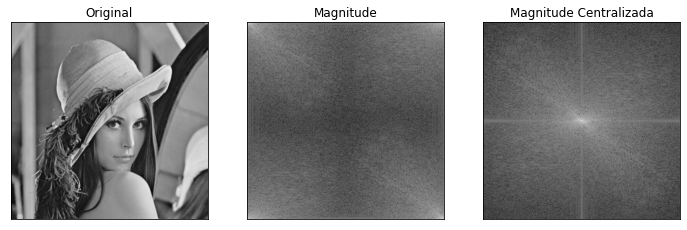

In [ ]:
#Gerando os resultados
plt.figure(figsize=(12,8))
plt.subplot (1,3,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Original'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,2)
plt.imshow(fourier1,cmap=plt.cm.gray)
plt.title('Magnitude'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,3)
plt.imshow(np.log(1+np.abs(center)),cmap=plt.cm.gray)
plt.title('Magnitude Centralizada'),plt.xticks([]), plt.yticks([])
plt.show()

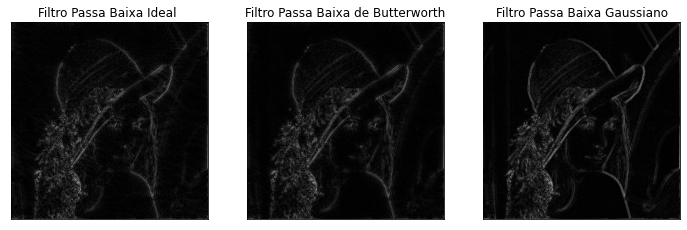

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot (1,3,1)
plt.imshow(np.abs(inverse_HighPassIdeal),cmap=plt.cm.gray)
plt.title('Filtro Passa Baixa Ideal '),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,2)
plt.imshow(np.abs(inverse_HighPassBut),cmap=plt.cm.gray)
plt.title('Filtro Passa Baixa de Butterworth'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,3)
plt.imshow(np.abs(inverse_HighPassGauss),cmap=plt.cm.gray)
plt.title('Filtro Passa Baixa Gaussiano'),plt.xticks([]), plt.yticks([])
plt.show()